In [749]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import pickle
from utils2 import get_classifier_metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import f1_score

## Paso 1. Lectura del conjunto de datos procesado

In [750]:
file_path = '/workspaces/CarlosRestrepo-machine-learning-python/data/processed/diabetes.pkl'

# Abrir el archivo en modo binario de lectura ('rb')
with open(file_path, 'rb') as file:
    # Cargar el objeto (tu DataFrame) usando el manejador de archivo 'file'
    df = pickle.load(file)

## Paso 2. Selección de variables

In [751]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,0,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,0,26.6,0.351,31,0
2,8.0,183.0,64.0,29.0,0,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94,28.1,0.167,21,0
5,5.0,116.0,74.0,29.0,0,25.6,0.201,30,0


## Split

In [752]:
X = df.drop('Outcome', axis=1)
y =df['Outcome']


X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

## Paso 3. Modelado

In [753]:
xgb = XGBClassifier(n_estimators=200,
                    learning_rate=0.1,
                    random_state=18,
                    use_label_encoder=False,
                    eval_metric='mlogloss')
ada = AdaBoostClassifier(n_estimators=200,
                         learning_rate=0.1,
                         random_state=18)
gb = GradientBoostingClassifier(n_estimators=200,
                                learning_rate=0.1,
                                random_state=18)
lgb = LGBMClassifier(n_estimators=200,
                     learning_rate=0.1,
                     random_state=18)

### 3.1. Entrenamiento

In [754]:
ada.fit(X_train, y_train)

,estimator,None
,n_estimators,200
,learning_rate,0.1
,algorithm,'deprecated'
,random_state,18


In [755]:
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [756]:
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [757]:
lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 200, number of negative: 393
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 641
[LightGBM] [Info] Number of data points in the train set: 593, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.337268 -> initscore=-0.675492
[LightGBM] [Info] Start training from score -0.675492
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [758]:
# predicción
ada_y_pred_test = ada.predict(X_test)
gb_y_pred_test = gb.predict(X_test)
xgb_y_pred_test = xgb.predict(X_test)
lgb_y_pred_test = lgb.predict(X_test)

ada_y_pred_train = ada.predict(X_train)
gb_y_pred_train = gb.predict(X_train)
xgb_y_pred_train = xgb.predict(X_train)
lgb_y_pred_train = lgb.predict(X_train)

In [759]:
accuracy_train = (accuracy_score(y_train, ada_y_pred_train),
                  accuracy_score(y_train, gb_y_pred_train),
                  accuracy_score(y_train, xgb_y_pred_train),
                  accuracy_score(y_train, lgb_y_pred_train))

accuracy_test = (accuracy_score(y_test, ada_y_pred_test),
                 accuracy_score(y_test, gb_y_pred_test),
                 accuracy_score(y_test, xgb_y_pred_test),
                 accuracy_score(y_test, lgb_y_pred_test))

accuracy = pd.DataFrame(data=[accuracy_train, accuracy_test],
                        columns=['AdaBoost', 'Gradient Boosting', 'XGBoost', 'LightGBM'],
                        index=['Train set', 'Test set'])

accuracy

,AdaBoost,Gradient Boosting,XGBoost,LightGBM
Train set,0.804384,0.994941,1.00000,1.00000
Test set,0.651007,0.697987,0.66443,0.66443


## Metricas de Random Forest 
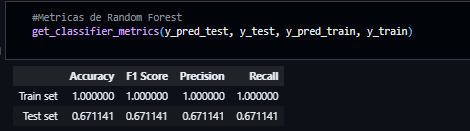

## Hiperparametrización de LGB

In [760]:
param_dist = {'n_estimators': [70, 75, 80],
              'reg_lambda': [0.6, 0.8, 0.9, 0.95, 1],
              'reg_alpha': [0.3, 0.5, 1],
              'learning_rate': [0.03, 0.05, 0.08, 0.1],
              'max_depth': [3, 4, 5],
              'gamma': [0.1, 0.5, 1, 2],
              'subsample': [0.6, 0.7, 0.8],
              'colsample_bytree': [0.7, 0.8, 0.9]
              }

random_search = RandomizedSearchCV(estimator=xgb,
                                   param_distributions=param_dist,
                                   scoring='f1',
                                   cv=5,
                                   verbose=1,
                                   random_state=18,
                                   n_jobs=-1)

In [761]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0.1, 0.5, ...], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,18
,error_score,nan


In [762]:
# 1. Mostrar los mejores resultados
random_search.best_score_

np.float64(0.6501534298260161)

In [763]:
random_search.best_params_

{'subsample': 0.8,
 'reg_lambda': 1,
 'reg_alpha': 1,
 'n_estimators': 70,
 'max_depth': 3,
 'learning_rate': 0.08,
 'gamma': 2,
 'colsample_bytree': 0.9}

In [764]:
best_model = random_search.best_estimator_
best_model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [765]:
y_pred_test = best_model.predict(X_test)
r2_test_final = f1_score(y_test, y_pred_test)
y_pred_train = best_model.predict(X_train)
r2_test_final

0.4731182795698925

In [766]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, 'macro')

,Accuracy,F1 Score,Precision,Recall
Train set,0.843170,0.818140,0.833196,0.808015
Test set,0.671141,0.617047,0.632798,0.613797


##### Observaciones:
>
>El modelo LightGBM optimizado es un punto de partida prometedor y robusto con 70.46% de precisión en la prueba, pero requiere una mayor simplificación para convertirse en una herramienta de predicción totalmente confiable y generalizable.